# Breast cancer dataset

In [6]:
# import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,confusion_matrix, classification_report

# Data loading and exploatin

In [7]:
# load kaggle Dataset
data=pd.read_csv("breast_cancer.csv")
print(data.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst  perimeter_worst  area_wor

In [16]:
# Data preorocessing
# Drop unnecessary column 
data.drop(['id'], axis=1, inplace=True)

# Convert diagnosis to binary 
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0}) 
 
X = data.drop('diagnosis', axis=1) 
y = data['diagnosis']

KeyError: "['id'] not found in axis"

In [10]:
#check missing values
print(data.isnull().sum())

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [15]:
data.shape

(569, 31)

In [17]:
# train-test split
X_train, X_test, y_train, y_test= train_test_split (X,y,test_size=0.25,random_state=42)

In [18]:
#Feature scaling(important)
scaler= StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [24]:
#train Logistic Regression model
model= LogisticRegression(max_iter=5000)
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [25]:
#make prediction
y_pred=model.predict(X_test)

In [21]:
#Model evaluation
print("Accuracy:", accuracy_score(y_test, y_pred)) 
 
print("\nConfusion Matrix:") 
print(confusion_matrix(y_test, y_pred)) 
 
print("\nClassification Report:") 
print(classification_report(y_test, y_pred)) 


Accuracy: 0.9790209790209791

Confusion Matrix:
[[87  2]
 [ 1 53]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98        89
           1       0.96      0.98      0.97        54

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



D:\Python 311\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


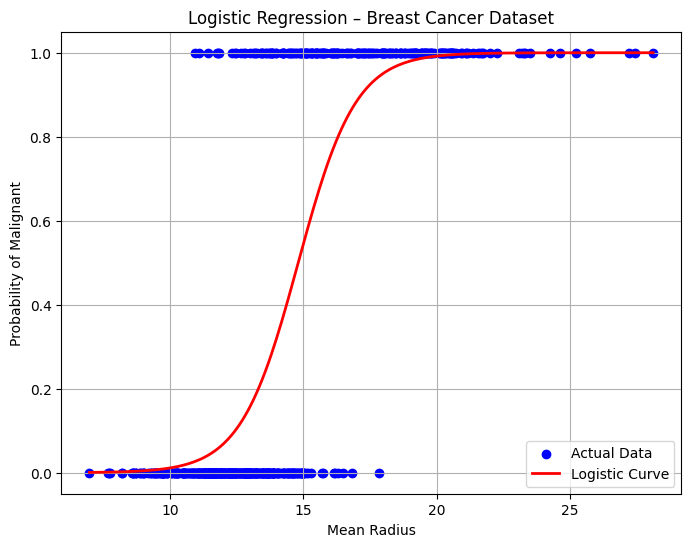

In [22]:
#Visualization 
X_feature = data[['radius_mean']] 
y = data['diagnosis'] 
 
X_train_f, X_test_f, y_train_f, y_test_f = train_test_split( 
    X_feature, y, test_size=0.25, random_state=42 
) 
 
model_f = LogisticRegression() 
model_f.fit(X_train_f, y_train_f) 
 
X_range = np.linspace(X_feature.min(), X_feature.max(), 200).reshape(-1,1) 
y_prob = model_f.predict_proba(X_range)[:,1] 
 
plt.figure(figsize=(8,6)) 
plt.scatter(X_feature, y, color='blue', label='Actual Data') 
plt.plot(X_range, y_prob, color='red', linewidth=2, label='Logistic Curve') 
plt.xlabel("Mean Radius") 
plt.ylabel("Probability of Malignant") 
plt.title("Logistic Regression – Breast Cancer Dataset") 
plt.legend() 
plt.grid(True) 
plt.show()

# Breast Cancer Prediction

In [2]:
# Import Required Libraries 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler 
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Data Loading and Exploration

In [3]:
# Load dataset 
df = pd.read_csv("breast_cancer.csv") 

In [4]:
# Display first five rows 
print("First Five Rows of Dataset") 
print(df.head()) 


First Five Rows of Dataset
         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  radius_worst  texture_worst

In [5]:
# Dataset shape 
print("\nDataset Shape:") 
print(df.shape) 
# Column names 
print("\nColumn Names:") 
print(df.columns) 


Dataset Shape:
(569, 32)

Column Names:
Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='str')


In [6]:
# Check missing values 
print("\nMissing Values:") 
print(df.isnull().sum()) 


Missing Values:
id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [7]:
# Statistical summary 
print("\nStatistical Summary:") 
print(df.describe()) 


Statistical Summary:
                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064 

In [8]:
# Statistical summary 
print("\nStatistical Summary:") 
print(df.describe()) 


Statistical Summary:
                 id  radius_mean  texture_mean  perimeter_mean    area_mean  \
count  5.690000e+02   569.000000    569.000000      569.000000   569.000000   
mean   3.037183e+07    14.127292     19.289649       91.969033   654.889104   
std    1.250206e+08     3.524049      4.301036       24.298981   351.914129   
min    8.670000e+03     6.981000      9.710000       43.790000   143.500000   
25%    8.692180e+05    11.700000     16.170000       75.170000   420.300000   
50%    9.060240e+05    13.370000     18.840000       86.240000   551.100000   
75%    8.813129e+06    15.780000     21.800000      104.100000   782.700000   
max    9.113205e+08    28.110000     39.280000      188.500000  2501.000000   

       smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064 


Diagnosis Count:
diagnosis
B    357
M    212
Name: count, dtype: int64


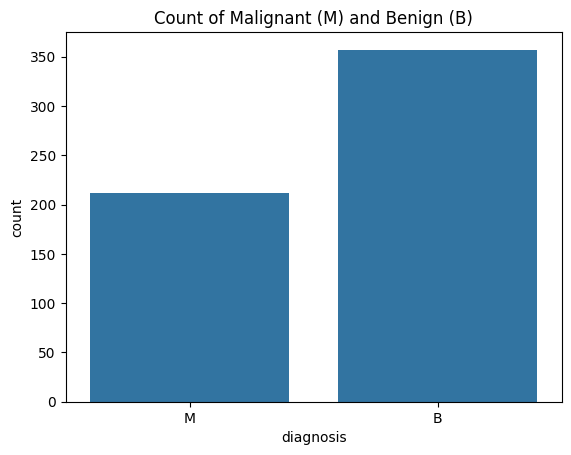

In [9]:
# Count of Malignant and Benign cases 
print("\nDiagnosis Count:") 
print(df['diagnosis'].value_counts()) 
# Visualization of diagnosis count 
sns.countplot(x='diagnosis', data=df) 
plt.title("Count of Malignant (M) and Benign (B)") 
plt.show()

# Data Preprocessing

In [11]:
# Encode target variable (M=1, B=0) 
df['diagnosis'] = df['diagnosis'].map({'M':1, 'B':0}) 

In [13]:
# Drop ID column if present 
if 'id' in df.columns: 
    df = df.drop('id', axis=1) 

In [14]:
# Separate features and target 
X = df.drop('diagnosis', axis=1) 
y = df['diagnosis'] 

In [15]:
# Feature Scaling 
scaler = StandardScaler() 
X_scaled = scaler.fit_transform(X) 

In [16]:
# Train Test Split (70-30) 
X_train, X_test, y_train, y_test = train_test_split( 
X_scaled, y, test_size=0.30, random_state=42)

# Implementation of KNN Algorithm

In [17]:
# Initial K value 
k = 5 
knn = KNeighborsClassifier(n_neighbors=k) 

In [18]:
# Initial K value 
k = 5 
knn = KNeighborsClassifier(n_neighbors=k) 

In [19]:
# Prediction 
y_pred = knn.predict(X_test) 

NotFittedError: This KNeighborsClassifier instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

# Model Evaluation

In [20]:
# Accuracy Score 
accuracy = accuracy_score(y_test, y_pred) 
print("\nAccuracy Score:", accuracy)

NameError: name 'y_pred' is not defined

In [21]:
# Confusion Matrix 
cm = confusion_matrix(y_test, y_pred) 
print("\nConfusion Matrix:") 
print(cm)

NameError: name 'y_pred' is not defined

In [22]:
# Visualization of Confusion Matrix 
sns.heatmap(cm, annot=True, cmap="Blues", fmt="d") 
plt.title("Confusion Matrix") 
plt.xlabel("Predicted") 
plt.ylabel("Actual") 
plt.show()

NameError: name 'cm' is not defined

In [23]:
# Precision, Recall, F1-score 
print("\nClassification Report:") 
print(classification_report(y_test, y_pred)) 


Classification Report:


NameError: name 'y_pred' is not defined

#  Hyperparameter Tuning (Finding Best K)

In [25]:
accuracy_list = [] 
for i in range(1,21): 
    knn = KNeighborsClassifier(n_neighbors=i) 
    knn.fit(X_train, y_train) 
    pred_i = knn.predict(X_test) 
    accuracy_list.append(accuracy_score(y_test, pred_i))

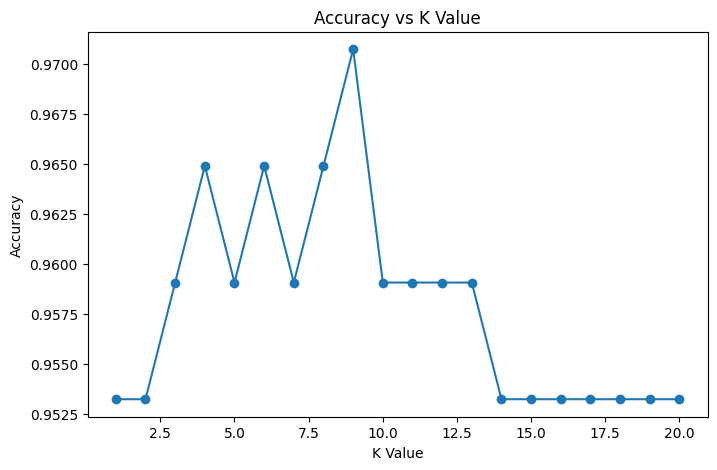

In [26]:
# Plot Accuracy vs K 
plt.figure(figsize=(8,5)) 
plt.plot(range(1,21), accuracy_list, marker='o') 
plt.title("Accuracy vs K Value") 
plt.xlabel("K Value") 
plt.ylabel("Accuracy") 
plt.show() 

In [27]:
# Best K value 
best_k = accuracy_list.index(max(accuracy_list)) + 1 
print("\nOptimal K Value:", best_k) 


Optimal K Value: 9


In [29]:
#Final Model with Optimal K 
knn_final = KNeighborsClassifier(n_neighbors=best_k) 
knn_final.fit(X_train, y_train) 
final_pred = knn_final.predict(X_test) 
final_accuracy = accuracy_score(y_test, final_pred) 
print("\nFinal Accuracy with Optimal K:", final_accuracy) 
print("\nFinal Confusion Matrix:") 
print(confusion_matrix(y_test, final_pred)) 
print("\nFinal Classification Report:") 
print(classification_report(y_test, final_pred))


Final Accuracy with Optimal K: 0.9707602339181286

Final Confusion Matrix:
[[106   2]
 [  3  60]]

Final Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       108
           1       0.97      0.95      0.96        63

    accuracy                           0.97       171
   macro avg       0.97      0.97      0.97       171
weighted avg       0.97      0.97      0.97       171

